In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import tree
# from sklearn.linear_model import LinearRegression ,LogisticRegression
# from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler,Normalizer,MinMaxScaler
# from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier,plot_tree  # here DecisionTreeClassifier is model
import sklearn.metrics as mt

In [8]:
# creating data frome here 
data = {
    'Age':           ['<=30', '<=30', '31-40', '>40', '>40', '>40', '31-40', '<=30', '<=30', '>40'],
    'Income':        ['High', 'High', 'High', 'Med', 'Low', 'Low', 'Low', 'Med', 'Low', 'Med'],
    'Student':       ['No', 'No', 'No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'Yes'],
    'Credit_Rating': ['Fair', 'Excellent', 'Fair', 'Fair', 'Fair', 'Excellent', 'Excellent', 'Fair', 'Fair', 'Fair'],
    'Buys_Computer': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes']
}

df = pd.DataFrame(data)
df.head()

,Age,Income,Student,Credit_Rating,Buys_Computer
0,<=30,High,No,Fair,No
1,<=30,High,No,Excellent,No
2,31-40,High,No,Fair,Yes
3,>40,Med,No,Fair,Yes
4,>40,Low,Yes,Fair,Yes


In [13]:
x=pd.get_dummies(df.drop("Buys_Computer",axis=1))
x.head()  # here target split for true false according to original data 

,Age_31-40,Age_<=30,Age_>40,Income_High,Income_Low,Income_Med,Student_No,Student_Yes,Credit_Rating_Excellent,Credit_Rating_Fair
0,False,True,False,True,False,False,True,False,False,True
1,False,True,False,True,False,False,True,False,True,False
2,True,False,False,True,False,False,True,False,False,True
3,False,False,True,False,False,True,True,False,False,True
4,False,False,True,False,True,False,False,True,False,True


In [17]:
y=df["Buys_Computer"].map({"No":0,"Yes":1})
y

0    0
1    0
2    1
3    1
4    1
5    0
6    1
7    0
8    1
9    1
Name: Buys_Computer, dtype: int64

In [28]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)  # random state = to fix the data 

In [29]:
x_train
x_test
y_train
y_test

8    1
1    0
5    0
Name: Buys_Computer, dtype: int64

In [30]:
x_train

,Age_31-40,Age_<=30,Age_>40,Income_High,Income_Low,Income_Med,Student_No,Student_Yes,Credit_Rating_Excellent,Credit_Rating_Fair
0,False,True,False,True,False,False,True,False,False,True
7,False,True,False,False,False,True,True,False,False,True
2,True,False,False,True,False,False,True,False,False,True
9,False,False,True,False,False,True,False,True,False,True
4,False,False,True,False,True,False,False,True,False,True
3,False,False,True,False,False,True,True,False,False,True
6,True,False,False,False,True,False,False,True,True,False


In [38]:
x_test

,Age_31-40,Age_<=30,Age_>40,Income_High,Income_Low,Income_Med,Student_No,Student_Yes,Credit_Rating_Excellent,Credit_Rating_Fair
8,False,True,False,False,True,False,False,True,False,True
1,False,True,False,True,False,False,True,False,True,False
5,False,False,True,False,True,False,False,True,True,False


In [32]:
 # imp paramter in DecisionTreeClassifier is ginni


In [35]:
model=DecisionTreeClassifier(criterion="entropy",random_state=0,max_depth=3)
model.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)

In [39]:
y_pread=model.predict(x_test) # prdiction is done for the target varriable 
y_pread

array([0, 0, 1], dtype=int64)

In [42]:
# ypread_train=model.predict(x_train)
# ypread_train

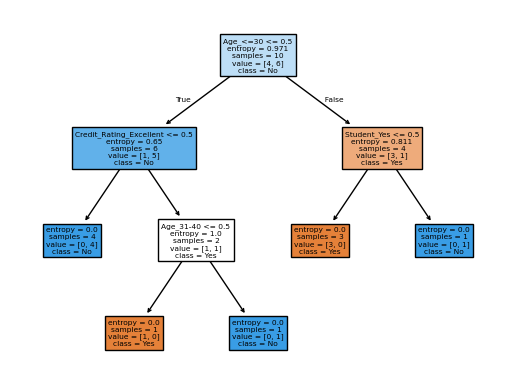

In [49]:
plt.figure(figure=(10,6));
plot_tree(model.fit(x,y),feature_names=x_train.columns,filled=True,class_names=["Yes","No"],);
plt.show()